## Business Case

The objective of this project is to build a predictive model that identifies the most suitable career domain for Computer Science students based on their academic performance, technical skills, and project experience. The system helps universities recommend personalized learning paths and improves placement success rate.

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [85]:
df = pd.read_csv('C:\\Users\\ramvi\\Downloads\\Student-Career-Prediction\\cs_students.csv')
df

,Student ID,Name,Gender,Age,GPA,Major,Interested Domain,Projects,Future Career,Python,SQL,Java
0,1,John Smith,Male,21,3.5,Computer Science,Artificial Intelligence,Chatbot Development,Machine Learning Researcher,Strong,Strong,Weak
1,2,Alice Johnson,Female,20,3.2,Computer Science,Data Science,Data Analytics,Data Scientist,Average,Strong,Weak
2,3,Robert Davis,Male,22,3.8,Computer Science,Software Development,E-commerce Website,Software Engineer,Strong,Strong,Average
3,4,Emily Wilson,Female,21,3.7,Computer Science,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong
4,5,Michael Brown,Male,23,3.4,Computer Science,Cybersecurity,Network Security,Information Security Analyst,Average,Weak,Strong
...,...,...,...,...,...,...,...,...,...,...,...,...
175,176,Elijah Davis,Male,22,3.7,Computer Science,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong
176,177,Emma Johnson,Female,20,3.6,Computer Science,Cybersecurity,Security Auditing,Information Security Analyst,Strong,Average,Weak
177,178,Liam Wilson,Male,21,3.4,Computer Science,Machine Learning,Natural Language Processing,Machine Learning Engineer,Strong,Average,Weak
178,179,Sophia Johnson,Female,22,3.5,Computer Science,Database Management,SQL Database Administration,Database Administrator,Weak,Strong,Average


## Basic Checks

In [86]:
df.head()

,Student ID,Name,Gender,Age,GPA,Major,Interested Domain,Projects,Future Career,Python,SQL,Java
0,1,John Smith,Male,21,3.5,Computer Science,Artificial Intelligence,Chatbot Development,Machine Learning Researcher,Strong,Strong,Weak
1,2,Alice Johnson,Female,20,3.2,Computer Science,Data Science,Data Analytics,Data Scientist,Average,Strong,Weak
2,3,Robert Davis,Male,22,3.8,Computer Science,Software Development,E-commerce Website,Software Engineer,Strong,Strong,Average
3,4,Emily Wilson,Female,21,3.7,Computer Science,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong
4,5,Michael Brown,Male,23,3.4,Computer Science,Cybersecurity,Network Security,Information Security Analyst,Average,Weak,Strong


In [87]:
df.tail()

,Student ID,Name,Gender,Age,GPA,Major,Interested Domain,Projects,Future Career,Python,SQL,Java
175,176,Elijah Davis,Male,22,3.7,Computer Science,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong
176,177,Emma Johnson,Female,20,3.6,Computer Science,Cybersecurity,Security Auditing,Information Security Analyst,Strong,Average,Weak
177,178,Liam Wilson,Male,21,3.4,Computer Science,Machine Learning,Natural Language Processing,Machine Learning Engineer,Strong,Average,Weak
178,179,Sophia Johnson,Female,22,3.5,Computer Science,Database Management,SQL Database Administration,Database Administrator,Weak,Strong,Average
179,180,Michael Brown,Male,23,3.7,Computer Science,Cloud Computing,Cloud Solution Architecture,Cloud Solutions Architect,Strong,Strong,Weak


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student ID         180 non-null    int64  
 1   Name               180 non-null    object 
 2   Gender             180 non-null    object 
 3   Age                180 non-null    int64  
 4   GPA                180 non-null    float64
 5   Major              180 non-null    object 
 6   Interested Domain  180 non-null    object 
 7   Projects           180 non-null    object 
 8   Future Career      180 non-null    object 
 9   Python             180 non-null    object 
 10  SQL                180 non-null    object 
 11  Java               180 non-null    object 
dtypes: float64(1), int64(2), object(9)
memory usage: 17.0+ KB


In [89]:
df.shape

(180, 12)

In [90]:
df.columns

Index(['Student ID', 'Name', 'Gender', 'Age', 'GPA', 'Major',
       'Interested Domain', 'Projects', 'Future Career', 'Python', 'SQL',
       'Java'],
      dtype='object')

In [91]:
df.describe()

,Student ID,Age,GPA
count,180.000000,180.000000,180.000000
mean,90.500000,22.116667,3.615000
std,52.105662,2.823040,0.177341
min,1.000000,20.000000,3.200000
25%,45.750000,21.000000,3.500000
50%,90.500000,22.000000,3.600000
75%,135.250000,22.250000,3.700000
max,180.000000,37.000000,3.900000


In [92]:
df.drop(['Student ID','Name'],axis=1,inplace=True)

In [93]:
df.head()

,Gender,Age,GPA,Major,Interested Domain,Projects,Future Career,Python,SQL,Java
0,Male,21,3.5,Computer Science,Artificial Intelligence,Chatbot Development,Machine Learning Researcher,Strong,Strong,Weak
1,Female,20,3.2,Computer Science,Data Science,Data Analytics,Data Scientist,Average,Strong,Weak
2,Male,22,3.8,Computer Science,Software Development,E-commerce Website,Software Engineer,Strong,Strong,Average
3,Female,21,3.7,Computer Science,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong
4,Male,23,3.4,Computer Science,Cybersecurity,Network Security,Information Security Analyst,Average,Weak,Strong


## Missing Values

In [94]:
df.isnull().sum()

Gender               0
Age                  0
GPA                  0
Major                0
Interested Domain    0
Projects             0
Future Career        0
Python               0
SQL                  0
Java                 0
dtype: int64

## Duplicates Values

In [95]:
df.duplicated().sum()

np.int64(52)

In [96]:
df=df.drop_duplicates()

## outLiers Detection(IQR)

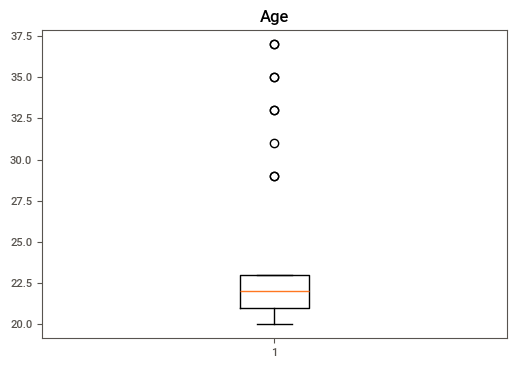

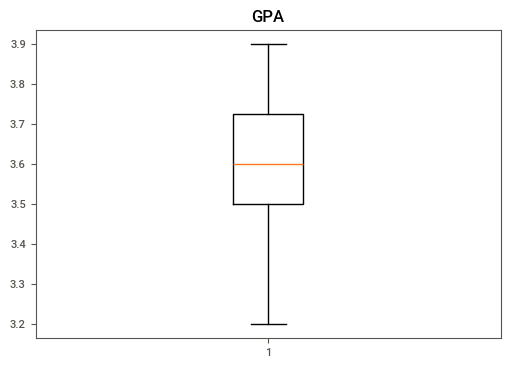

In [97]:
num_col=df.select_dtypes(include=np.number).columns
for col in num_col:
    plt.figure(figsize=(6,4))
    plt.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## Remove Outliers

In [98]:
# compute quartiles only for numeric columns
Q1 = df[num_col].quantile(0.25)
Q3 = df[num_col].quantile(0.75)
IQR = Q3 - Q1

min_limit = Q1 - 1.5 * IQR
max_limit = Q3 + 1.5 * IQR

# mask rows where any numeric value lies outside the limits
mask = (df[num_col] < min_limit) | (df[num_col] > max_limit)
outliers = df[mask.any(axis=1)]

# counts/percentages per numeric column
outliers_count = mask.sum()
outliers_percentage = (outliers_count / len(df)) * 100

print('\n sum of outliers in each numeric column:\n', outliers_count)
print('\n percentage of outliers in each numeric column:\n', outliers_percentage)


 sum of outliers in each numeric column:
 Age    9
GPA    0
dtype: int64

 percentage of outliers in each numeric column:
 Age    7.03125
GPA    0.00000
dtype: float64


In [99]:
Q1=df.Age.quantile(0.25)

Q3=df.Age.quantile(0.75)

IQR=Q3-Q1

LB=Q1-1.5*IQR

UB=Q3+1.5*IQR

df.loc[(df.Age<LB)|(df.Age>UB),'Age']=np.median(df.Age)

In [100]:
df.loc[(df.Age<LB)|(df.Age>UB)]

,Gender,Age,GPA,Major,Interested Domain,Projects,Future Career,Python,SQL,Java


## EDA

### Univariate Analysis

In [101]:
import sweetviz as sv
report = sv.analyze(df)
report.show_html('report.html')

                                             |          | [  0%]   00:00 -> (? left)

Report report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


### Bivariate Analysis

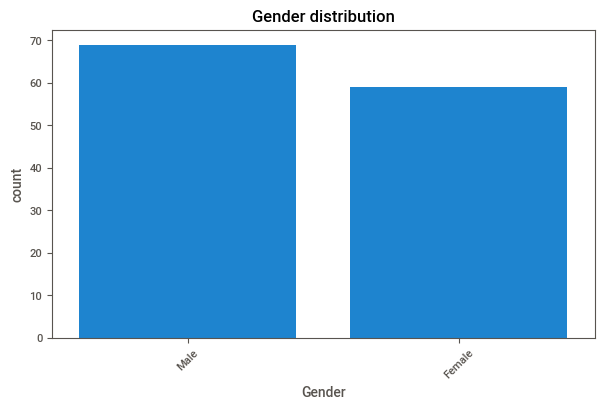

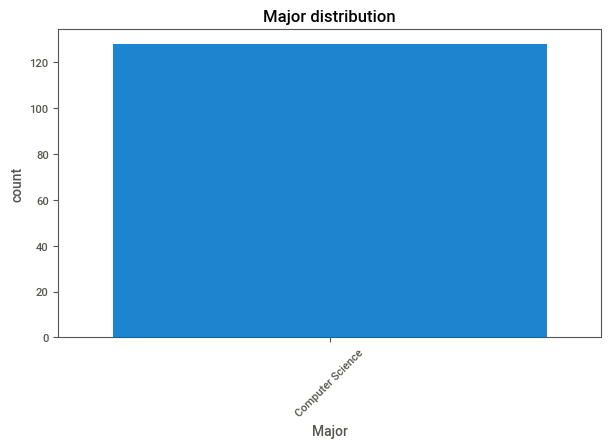

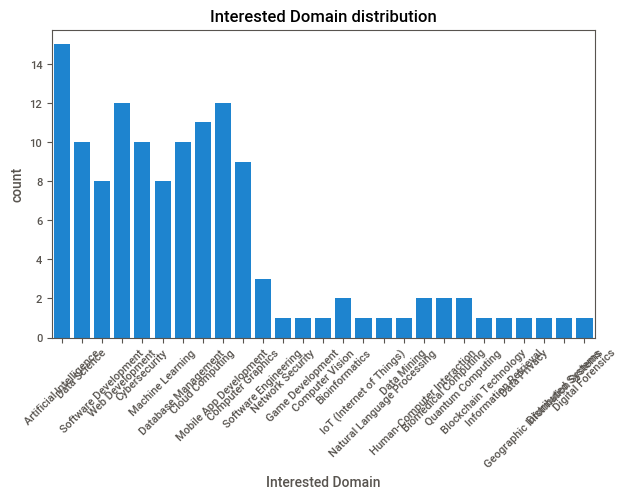

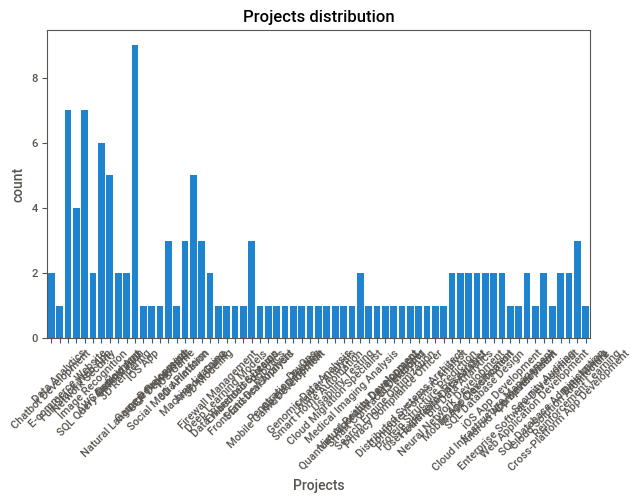

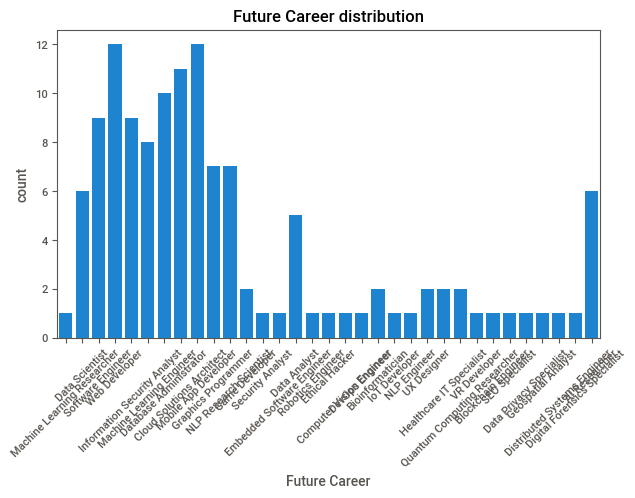

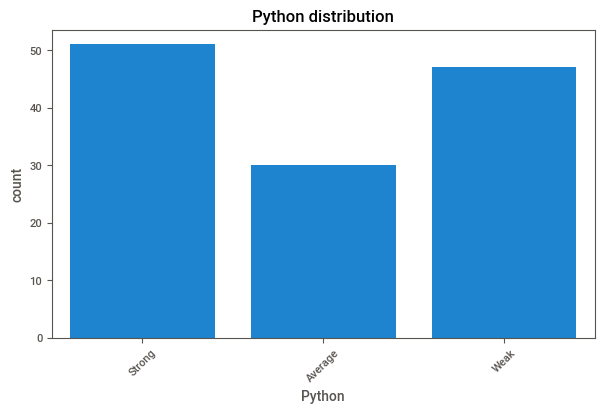

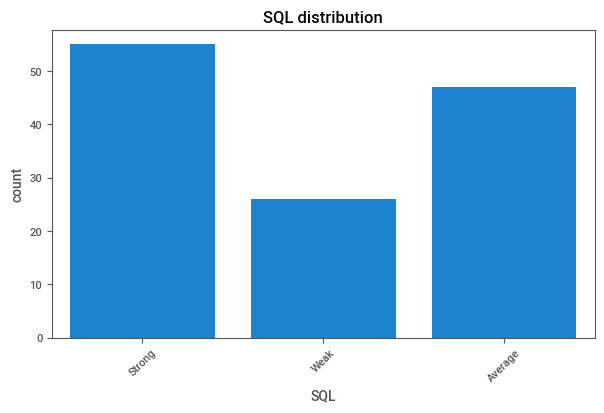

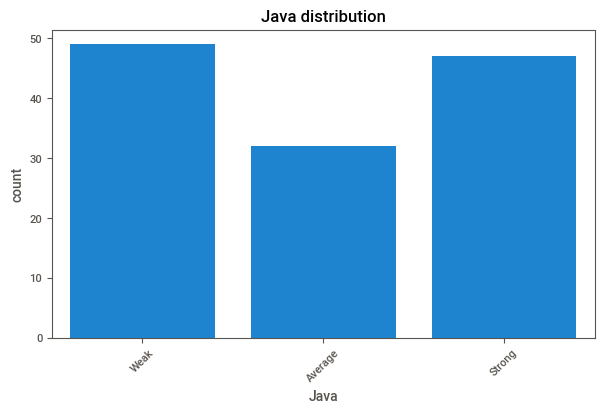

In [102]:
cat_col=df.select_dtypes(include='object').columns
for col in cat_col:
    plt.figure(figsize=(7,4))
    sns.countplot(x=df[col])
    plt.title(f'{col} distribution')
    plt.xticks(rotation=45)
    plt.show()

#### GPA vs Future Career

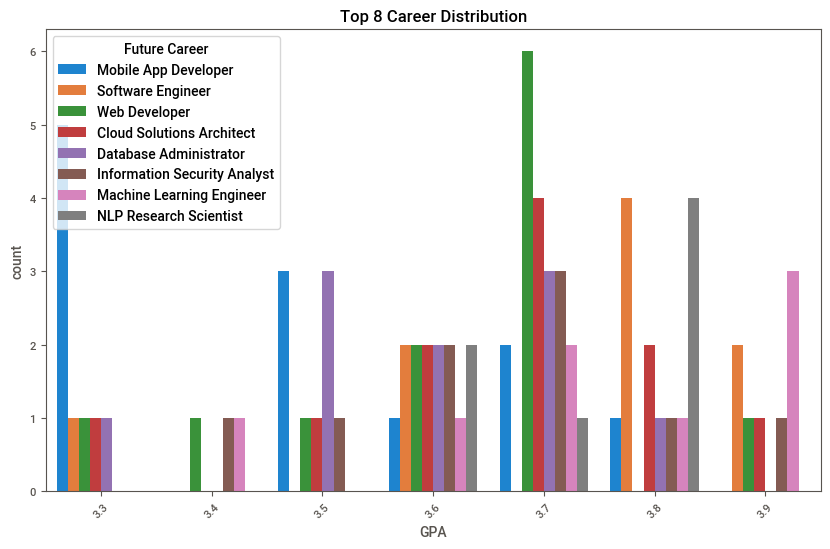

In [103]:
top_career=df['Future Career'].value_counts().nlargest(8).index
df_top=df[df['Future Career'].isin(top_career)]
plt.figure(figsize=(10,6))
sns.countplot(x='GPA',hue='Future Career',data=df_top)
plt.title('Top 8 Career Distribution')
plt.xticks(rotation=45)
plt.show()

#### Skills vs Future Career

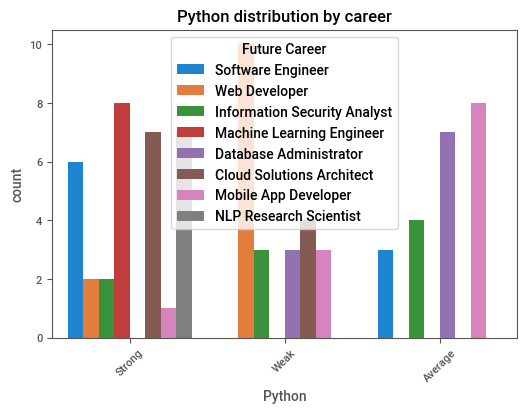

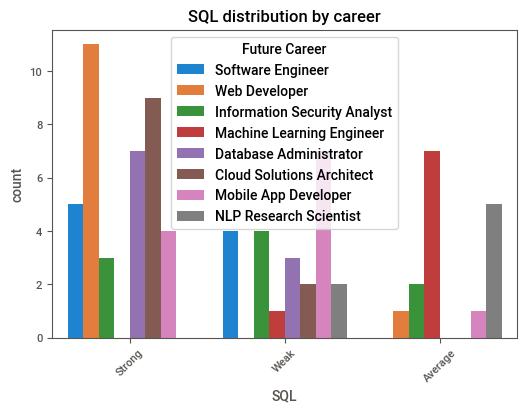

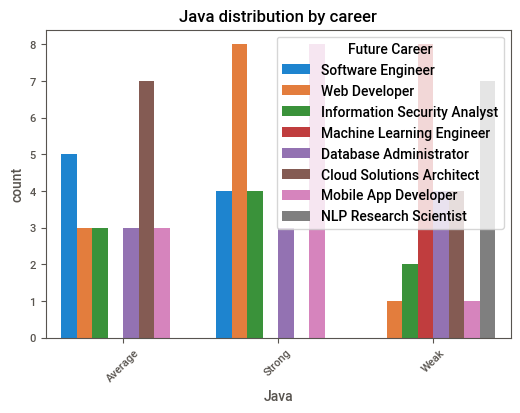

In [104]:
skills=['Python','SQL','Java']
for skill in skills:
    plt.figure(figsize=(6,4))
    sns.countplot(x=skill,hue='Future Career',data=df_top)
    plt.title(f'{skill} distribution by career')
    plt.xticks(rotation=45)
    plt.show()

### MultiVariate Analysis

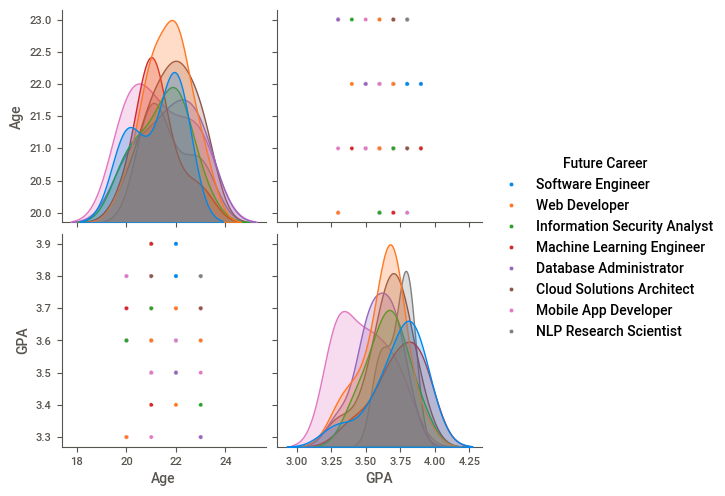

In [105]:
sns.pairplot(df_top,hue='Future Career')
plt.show()

## Encoding

In [106]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [107]:
df.Gender.value_counts()

Gender
Male      69
Female    59
Name: count, dtype: int64

In [108]:
df['Gender']=le.fit_transform(df['Gender'])

In [109]:
df.Major.value_counts()

Major
Computer Science    128
Name: count, dtype: int64

In [110]:
df['Major']=le.fit_transform(df['Major'])

In [111]:
df.rename(columns={'Future Career':'Future_Career'},inplace=True)

In [112]:
df['Future_Career']=le.fit_transform(df['Future_Career'])

In [113]:
df.rename(columns={'Interested Domain':'Interested_Domain'},inplace=True)

In [114]:
df['Interested_Domain']=le.fit_transform(df['Interested_Domain'])

In [115]:
df.Python.value_counts()

Python
Strong     51
Weak       47
Average    30
Name: count, dtype: int64

In [116]:
df['Python']=le.fit_transform(df['Python'])

In [117]:
df.Java.value_counts()

Java
Weak       49
Strong     47
Average    32
Name: count, dtype: int64

In [118]:
df['Java']=le.fit_transform(df['Java'])

In [119]:
df.SQL.value_counts()

SQL
Strong     55
Average    47
Weak       26
Name: count, dtype: int64

In [120]:
df['SQL']=le.fit_transform(df['SQL'])

In [121]:
df['Projects']=le.fit_transform(df['Projects'])

In [122]:
df.head()

,Gender,Age,GPA,Major,Interested_Domain,Projects,Future_Career,Python,SQL,Java
0,1,21,3.5,0,0,8,21,1,1,2
1,0,20,3.2,0,10,15,7,0,1,2
2,1,22,3.8,0,24,21,29,1,1,0
3,0,21,3.7,0,26,26,32,2,1,1
4,1,23,3.4,0,7,40,18,0,2,1


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128 entries, 0 to 166
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             128 non-null    int64  
 1   Age                128 non-null    int64  
 2   GPA                128 non-null    float64
 3   Major              128 non-null    int64  
 4   Interested_Domain  128 non-null    int64  
 5   Projects           128 non-null    int64  
 6   Future_Career      128 non-null    int64  
 7   Python             128 non-null    int64  
 8   SQL                128 non-null    int64  
 9   Java               128 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 11.0 KB


In [124]:
df.GPA.value_counts()

GPA
3.7    30
3.8    22
3.6    22
3.5    21
3.3    15
3.9    10
3.4     6
3.2     2
Name: count, dtype: int64

## Heatmap

<Axes: >

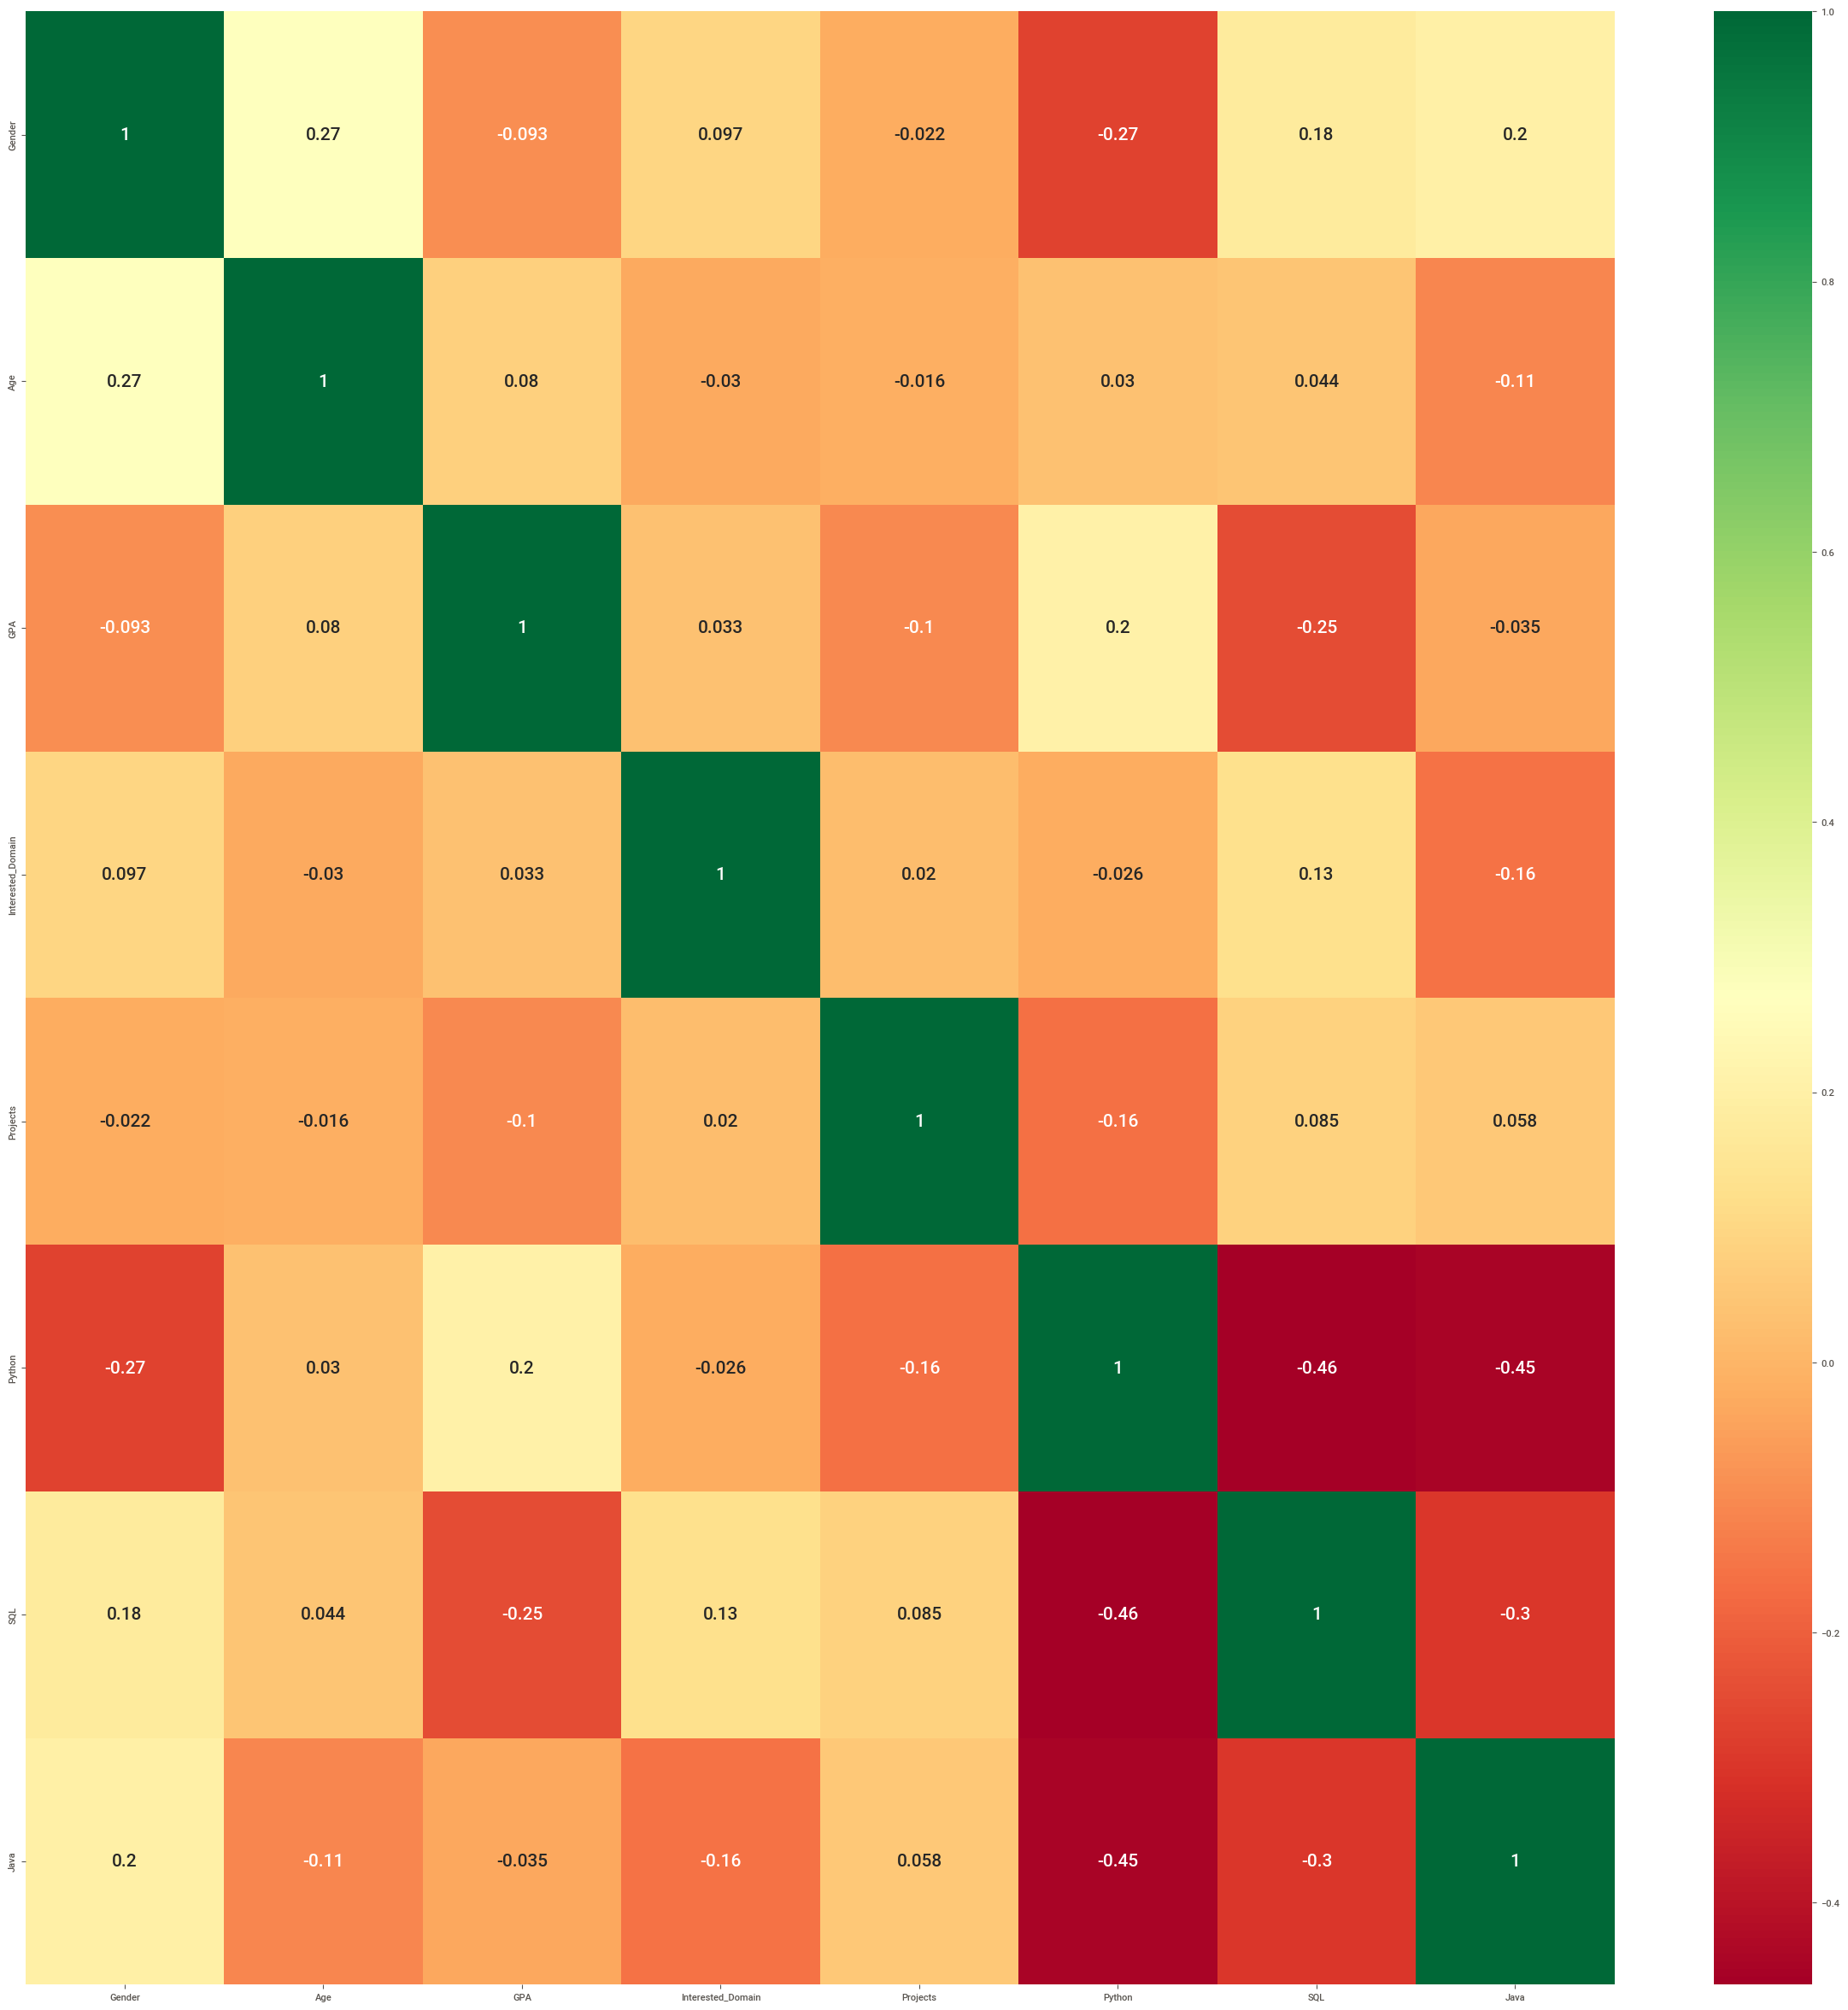

In [125]:
plt.figure(figsize=(30, 30))
sns.heatmap(df.drop(['Future_Career','Major'],axis=1).corr(),annot=True,cmap='RdYlGn',annot_kws={'size':15})

## Train Test Split

In [126]:
x=df.iloc[:,:-1]
y=df.Future_Career

In [127]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [128]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)   
print(y_test.shape)

(102, 9)
(26, 9)
(102,)
(26,)


## Scaling

In [129]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaler=scaler.fit_transform(x_train[x_train.columns])
x_test_scaler=scaler.transform(x_test[x_test.columns])

## Model Implementation

#### Logistic Regression

In [130]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,roc_auc_score,roc_curve,accuracy_score,precision_score,recall_score,f1_score

In [131]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train_scaler,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [132]:
y_pred=model.predict(x_test_scaler)

In [133]:
print('accuracy_score',accuracy_score(y_test,y_pred))

accuracy_score 0.6153846153846154


In [134]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           3       0.75      1.00      0.86         3
           5       0.00      0.00      0.00         1
           7       0.50      1.00      0.67         1
           8       0.50      0.50      0.50         2
          16       1.00      1.00      1.00         2
          18       0.00      0.00      0.00         1
          20       0.00      0.00      0.00         0
          22       0.50      0.50      0.50         2
          23       0.00      0.00      0.00         1
          24       1.00      1.00      1.00         3
          25       0.00      0.00      0.00         2
          29       0.67      1.00      0.80         2
          32       1.00      0.50      0.67         4

    accuracy                           0.62        26
   macro avg       0.49      0.50      0.48        26
weighted avg       0.66      0.62      0.61        26



In [135]:
print(precision_score(y_test,y_pred,average='weighted'))

0.6570512820512822


#### KNN

In [136]:
from sklearn.neighbors import KNeighborsClassifier
model1=KNeighborsClassifier(n_neighbors=5)
model1.fit(x_train_scaler,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [137]:
y_pred=model1.predict(x_test_scaler)

In [138]:
print('accuracy_score',accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

accuracy_score 0.6153846153846154
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           3       0.75      1.00      0.86         3
           5       0.00      0.00      0.00         1
           7       0.33      1.00      0.50         1
           8       0.00      0.00      0.00         2
          16       1.00      1.00      1.00         2
          18       0.00      0.00      0.00         1
          20       0.00      0.00      0.00         0
          22       0.50      0.50      0.50         2
          23       0.00      0.00      0.00         1
          24       1.00      1.00      1.00         3
          25       0.00      0.00      0.00         2
          29       1.00      0.50      0.67         2
          32       1.00      1.00      1.00         4

    accuracy                           0.62        26
   macro avg       0.47      0.46      0.44        26
weighted avg       0.64      0.62      0.61   

In [139]:
print(precision_score(y_test,y_pred,average='weighted'))

0.6378205128205128


#### Decision Tree

In [140]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_train_scaler,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [141]:
y_pred=dt.predict(x_test_scaler)

In [142]:
print('accuracy_score',accuracy_score(y_test,y_pred))

accuracy_score 0.8461538461538461


In [143]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         3
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         0
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         2
          18       1.00      1.00      1.00         1
          22       0.67      1.00      0.80         2
          23       0.00      0.00      0.00         1
          24       1.00      1.00      1.00         3
          25       0.00      0.00      0.00         2
          28       0.00      0.00      0.00         0
          29       1.00      1.00      1.00         2
          32       1.00      1.00      1.00         4

    accuracy                           0.85        26
   macro avg       0.64      0.67      0.65        26
weighted avg       0.82   

In [144]:
print(confusion_matrix(y_test,y_pred))

[[2 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 3 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 2 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 2 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 2 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 3 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 2 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 2 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 4]]


#### Random Forest

In [145]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(x_train_scaler,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [146]:
y_pred=rf.predict(x_test_scaler)

In [147]:
print('accuracy_score',accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

accuracy_score 0.8846153846153846
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         2
          18       1.00      1.00      1.00         1
          22       0.67      1.00      0.80         2
          23       0.00      0.00      0.00         1
          24       1.00      1.00      1.00         3
          25       0.00      0.00      0.00         2
          28       0.00      0.00      0.00         0
          29       1.00      1.00      1.00         2
          32       1.00      1.00      1.00         4

    accuracy                           0.88        26
   macro avg       0.76      0.79      0.77        26
weighted avg       0.86      0.88      0.87   

#### SVM

In [148]:
from sklearn.svm import SVC
svc=SVC(kernel='linear')
svc.fit(x_train_scaler,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [149]:
y_pred=svc.predict(x_test_scaler)

In [150]:
accuracy_score(y_test,y_pred)

0.5384615384615384

#### Naive Bayes

In [151]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(x_train_scaler,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [152]:
y_pred=nb.predict(x_test_scaler)

In [153]:
accuracy_score(y_test,y_pred)

0.8076923076923077

## Model Comparison

In [154]:
models = {
    'Logistic Regression': model,
    'K-Nearest Neighbors': model1,
    'Decision Tree': dt,
    'Random Forest': rf,
    'Support Vector Machine': svc,
    'Naive Bayes': nb
}
results={}
for name, model in models.items():
    pred=model.predict(x_test_scaler)
    results[name]=accuracy_score(y_test,pred)

pd.DataFrame.from_dict(results,orient='index',columns=['Accuracy']).sort_values(by='Accuracy',ascending=False)

,Accuracy
Random Forest,0.884615
Decision Tree,0.846154
Naive Bayes,0.807692
Logistic Regression,0.615385
K-Nearest Neighbors,0.615385
Support Vector Machine,0.538462


## Feature Importance

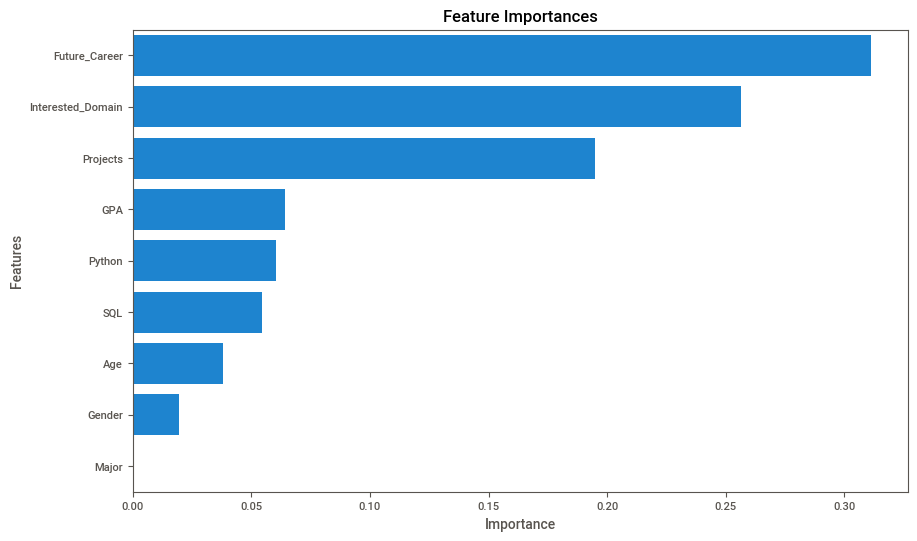

In [157]:
rf.fit(x_train_scaler,y_train)
importances=pd.Series(rf.feature_importances_,index=x_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importances,y=importances.index)
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

## Cross Validation

In [158]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

In [159]:
rf=RandomForestClassifier(random_state=42)
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_score=cross_val_score(rf,x_train_scaler,y_train,cv=skf,scoring='accuracy')
print('Cross-Validation Accuracy Scores:', cv_score)
print('Mean Cross-Validation Accuracy:', cv_score.mean())

Cross-Validation Accuracy Scores: [0.66666667 0.85714286 0.9        0.8        0.7       ]
Mean Cross-Validation Accuracy: 0.7847619047619048


## Hyperparameter Tuning

In [160]:
### RandomizedSearchCV
param_dist={
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}
rf=RandomForestClassifier(random_state=42)
random_search=RandomizedSearchCV(rf,param_distributions=param_dist,n_iter=50,cv=skf,scoring='accuracy',n_jobs=-1,random_state=42)
random_search.fit(x_train_scaler,y_train)
print('Best Hyperparameters:', random_search.best_params_)
print('Best Cross-Validation Accuracy:', random_search.best_score_)

Best Hyperparameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 10}
Best Cross-Validation Accuracy: 0.8147619047619047


In [161]:
## GridSearchCV
param_grid={
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}
Grid_search=GridSearchCV(RandomForestClassifier(random_state=42),param_grid=param_grid,cv=skf,scoring='accuracy',n_jobs=-1)
Grid_search.fit(x_train_scaler,y_train)
print('Best Hyperparameters:', Grid_search.best_params_)
print('Best Cross-Validation Accuracy:', Grid_search.best_score_)

Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best Cross-Validation Accuracy: 0.7852380952380953


In [162]:
best_model=random_search.best_estimator_
y_pred=best_model.predict(x_test_scaler)
print('Final Accuracy Score:', accuracy_score(y_test,y_pred))
print('Final Classification Report:', classification_report(y_test,y_pred))

Final Accuracy Score: 0.8846153846153846
Final Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         2
          18       1.00      1.00      1.00         1
          22       0.67      1.00      0.80         2
          23       0.00      0.00      0.00         1
          24       1.00      1.00      1.00         3
          25       0.00      0.00      0.00         2
          28       0.00      0.00      0.00         0
          29       1.00      1.00      1.00         2
          32       1.00      1.00      1.00         4

    accuracy                           0.88        26
   macro avg       0.76      0.79      0.77        26
weighted a

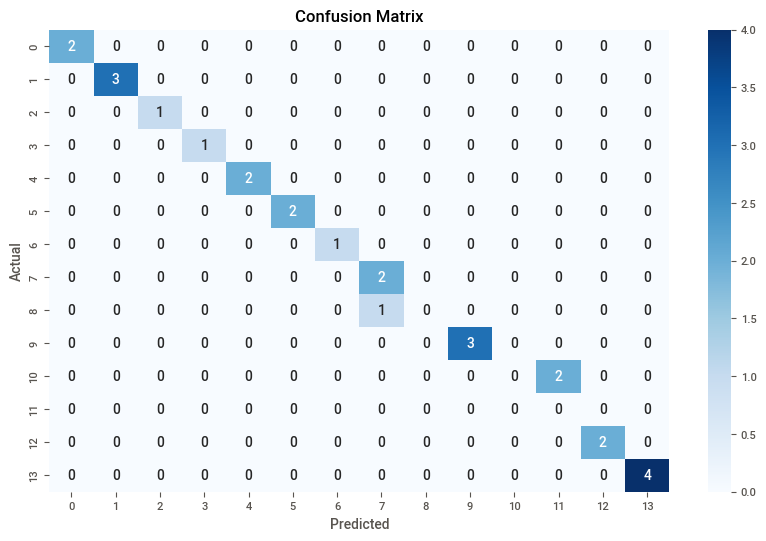

In [163]:
plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,cmap='Blues',fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Cross VAlidation of final Model

In [164]:
final_cv=cross_val_score(best_model,x_train_scaler,y_train,cv=skf,scoring='accuracy')
print('Final cross Validation Accuracy Scores:', final_cv)
print('Final mean cv score:', final_cv.mean())

Final cross Validation Accuracy Scores: [0.66666667 0.85714286 0.9        0.8        0.85      ]
Final mean cv score: 0.8147619047619047
